# SHAP interpretation of the CatBoost model

CatBoost didn't beat Logistic Regression on PR-AUC, but it's the strongest tree model, and its non-linear structure makes it a more natural fit for SHAP. This notebook doesn't change the model or try to improve it, it just asks which of the 15 longitudinal features the fixed CatBoost model from the previous notebook actually relies on, and in what direction.

In [1]:
import shap
print("shap version:", shap.__version__)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap version: 0.52.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier

pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
long = pd.read_csv("../outputs/inspection_level_longitudinal.csv",
                    parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)
print("prediction rows:", len(pred))

prediction rows: 69766


## Rebuild the 730-day features and 15-feature set

Same construction as the previous two notebooks.

In [3]:
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_730(g):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    total_infr = g["n_infractions"].to_numpy()
    crucial = g["n_crucial"].to_numpy()
    non_pass = g["is_non_pass"].to_numpy()

    cs_infr = np.concatenate([[0], np.cumsum(total_infr)])
    cs_crucial = np.concatenate([[0], np.cumsum(crucial)])
    cs_nonpass = np.concatenate([[0], np.cumsum(non_pass)])

    lower_edge = dates - np.timedelta64(730, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")

    idx_arr = np.arange(len(g))
    return pd.DataFrame({
        "orig_index": g["index"],
        "prior_730d_n_inspections": idx_arr - low_idx,
        "prior_730d_n_non_pass": cs_nonpass[idx_arr] - cs_nonpass[low_idx],
        "prior_730d_total_infractions": cs_infr[idx_arr] - cs_infr[low_idx],
        "prior_730d_crucial_infractions": cs_crucial[idx_arr] - cs_crucial[low_idx],
    })

rolled = long.groupby("estId", group_keys=False).apply(rolling_730).set_index("orig_index")
long_feat = long.join(rolled)

hist_730 = long_feat[["estId", "inspectionDate", "prior_730d_n_inspections", "prior_730d_n_non_pass",
                       "prior_730d_total_infractions", "prior_730d_crucial_infractions"]]

df = pred.merge(hist_730, on=["estId", "inspectionDate"], how="left")
assert len(df) == len(pred)
assert df["prior_730d_n_inspections"].isna().sum() == 0

In [4]:
BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]

FEATURES = BASE + HIST365 + HIST730
assert len(FEATURES) == 15

identifier_cols = {"estId", "oldEstId", "_id", "unique_id"}
outcome_cols = {"OutcomeDate", "OutcomeDesc", "amountFined", "inspectionStatus"}
assert identifier_cols.isdisjoint(FEATURES)
assert outcome_cols.isdisjoint(FEATURES)
FEATURES

['days_since_previous_inspection',
 'prev_non_pass',
 'prev_total_infractions',
 'prev_minor',
 'prev_significant',
 'prev_crucial',
 'n_inspections_seen_so_far',
 'prior_365d_n_inspections',
 'prior_365d_n_non_pass',
 'prior_365d_total_infractions',
 'prior_365d_crucial_infractions',
 'prior_730d_n_inspections',
 'prior_730d_n_non_pass',
 'prior_730d_total_infractions',
 'prior_730d_crucial_infractions']

## Same strict split as Prompts 8-11

In [5]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
val = df[(df["inspectionDate"] >= train_cut) & (df["inspectionDate"] < val_cut)].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

assert len(train) == 45334 and len(val) == 11740 and len(test) == 12692
assert train["inspectionDate"].max() < val["inspectionDate"].min()
assert val["inspectionDate"].max() < test["inspectionDate"].min()
print("split matches Prompts 8-11 exactly")

X_train, y_train = train[FEATURES], train["target"]
X_test, y_test = test[FEATURES], test["target"]

split matches Prompts 8-11 exactly


## Train the fixed CatBoost model

Exact same configuration as Prompt 11, not tuned here.

In [6]:
model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False,
)
model.fit(X_train, y_train)
print("trained")

trained


## SHAP values on a fixed test sample

Using a fixed sample of up to 2,000 test rows rather than the full test set, this is only for interpreting the already-trained model, no retraining or feature/threshold selection happens here.

In [7]:
sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
print("SHAP sample size:", len(sample))

explainer = shap.TreeExplainer(model)
shap_values = explainer(sample)
print("shap values shape:", shap_values.values.shape)

SHAP sample size: 2000
shap values shape: (2000, 15)


## Checking which class the SHAP values correspond to

CatBoost's binary `Logloss` model has one output, so `TreeExplainer` returns a single 2D array of shape (rows, features), already on the log-odds scale for the model's single output, which corresponds to the positive class (Non-Pass = 1). If a 3D array had been returned instead (some SHAP/model combinations do this), index 1 along the last axis would be selected explicitly.

In [8]:
vals = shap_values.values
if vals.ndim == 3:
    print("3D output detected, selecting class 1 (Non-Pass)")
    vals = vals[:, :, 1]
else:
    print("2D output, already corresponds to the model's single (Non-Pass) output")
print("final shap values shape used:", vals.shape)

2D output, already corresponds to the model's single (Non-Pass) output
final shap values shape used: (2000, 15)


## Global SHAP importance

In [9]:
mean_abs_shap = np.abs(vals).mean(axis=0)
shap_imp = pd.DataFrame({"feature": FEATURES, "mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_imp

,feature,mean_abs_shap
0,prior_730d_total_infractions,0.420775
1,days_since_previous_inspection,0.216381
2,prior_365d_total_infractions,0.193649
3,n_inspections_seen_so_far,0.135371
4,prev_non_pass,0.132128
5,prev_minor,0.083149
6,prior_730d_n_non_pass,0.076817
7,prior_730d_n_inspections,0.068727
8,prev_total_infractions,0.068282
9,prior_365d_n_inspections,0.065098


Larger mean absolute SHAP values mean the feature has a greater average contribution to the CatBoost model's predictions for this sample, not that the feature is more "dangerous" or more strongly causal.

## SHAP summary plot

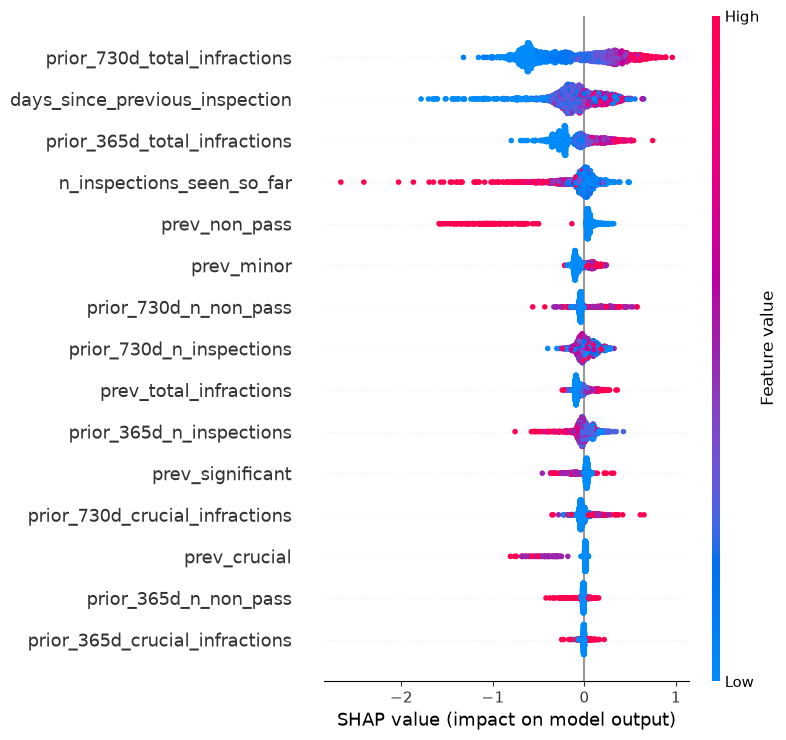

In [10]:
shap_values_for_plot = shap.Explanation(values=vals, base_values=shap_values.base_values,
                                          data=sample.values, feature_names=FEATURES)
shap.summary_plot(shap_values_for_plot, sample, show=False)
plt.tight_layout()
plt.savefig("../outputs/figures/catboost_shap_summary.png", dpi=100, bbox_inches="tight")
plt.show()

## Top 5 features

Checking direction with a simple correlation between each feature's raw value and its SHAP value across the sample, positive means higher feature values tend to push the prediction up, negative means the opposite.

In [11]:
top5 = shap_imp["feature"].head(5).tolist()
for f in top5:
    idx = FEATURES.index(f)
    corr = np.corrcoef(sample[f].values, vals[:, idx])[0, 1]
    print(f, "correlation(feature value, shap value):", round(corr, 3))

prior_730d_total_infractions correlation(feature value, shap value): 0.814
days_since_previous_inspection correlation(feature value, shap value): 0.456
prior_365d_total_infractions correlation(feature value, shap value): 0.795
n_inspections_seen_so_far correlation(feature value, shap value): -0.76
prev_non_pass correlation(feature value, shap value): -0.962


- `prior_730d_total_infractions` (largest attribution): strongly positive correlation, higher two-year infraction totals generally push the model toward higher predicted Non-Pass probability.
- `days_since_previous_inspection`: positive correlation, a longer gap since the last inspection tends to push the prediction up.
- `prior_365d_total_infractions`: positive correlation, similar pattern to the 730-day version, receives a large share of the model's attribution alongside it since the two overlap.
- `n_inspections_seen_so_far`: negative correlation, establishments with a longer inspection track record tend to get pushed toward lower predicted Non-Pass probability.
- `prev_non_pass`: negative correlation, at first this looks backwards (a Non-Pass last time pushing the prediction down), but this mirrors what the Logistic Regression coefficients showed too, likely because `prev_total_infractions` and the history-window infraction totals already carry most of the "recent trouble" signal, leaving `prev_non_pass` to pick up a smaller, partly offsetting share once those are accounted for. This is an artifact of overlapping features, not read as a real protective effect.

## Two dependence plots

Picking two of the more interpretable top features.

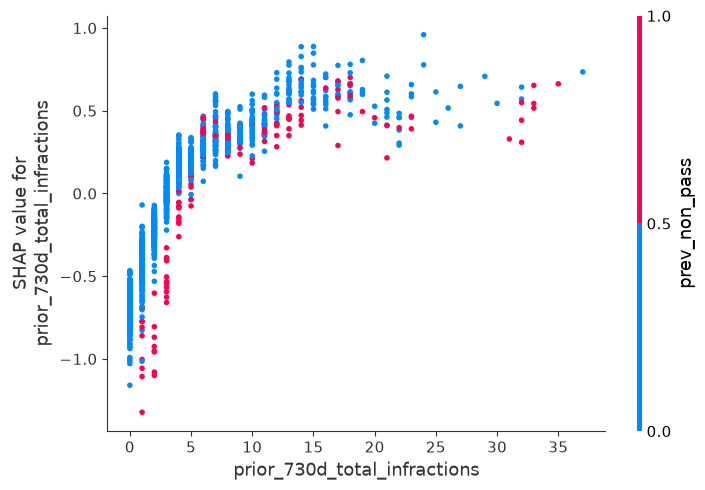

In [12]:
shap.dependence_plot("prior_730d_total_infractions", vals, sample, feature_names=FEATURES, show=False)
plt.tight_layout()
plt.savefig("../outputs/figures/catboost_shap_dependence_1.png", dpi=100, bbox_inches="tight")
plt.show()

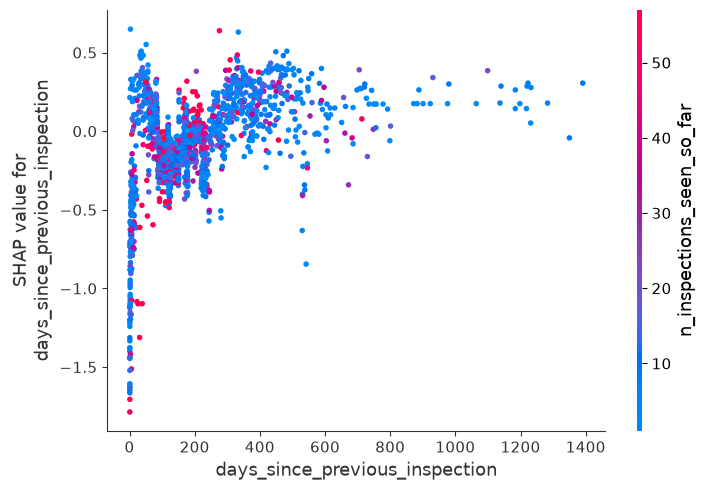

In [13]:
shap.dependence_plot("days_since_previous_inspection", vals, sample, feature_names=FEATURES, show=False)
plt.tight_layout()
plt.savefig("../outputs/figures/catboost_shap_dependence_2.png", dpi=100, bbox_inches="tight")
plt.show()

## Feature overlap caution

`prev_non_pass` / `prev_total_infractions`, the 365-day pair, and the 730-day pair all describe overlapping information (recent trouble at different time depths). Attribution gets distributed across these related features rather than concentrating cleanly on one, so a feature here should be read as receiving a large share of the model's attribution in this representation, not as being independently responsible for the prediction.

## Comparison with Prompt 11's built-in CatBoost importance

Just checking whether the broad ranking agrees, not a formal statistical comparison. The two measures answer different questions: built-in importance reflects how much a feature reduces the loss across all training splits, SHAP reflects each feature's average contribution to individual predictions on this test sample.

In [14]:
builtin_imp = pd.read_csv("../outputs/catboost_730d_feature_importance.csv")
comparison = shap_imp.merge(builtin_imp, on="feature", suffixes=("_shap", "_builtin"))
comparison["shap_rank"] = comparison["mean_abs_shap"].rank(ascending=False)
comparison["builtin_rank"] = comparison["importance"].rank(ascending=False)
comparison.sort_values("shap_rank")[["feature", "mean_abs_shap", "shap_rank", "importance", "builtin_rank"]]

,feature,mean_abs_shap,shap_rank,importance,builtin_rank
0,prior_730d_total_infractions,0.420775,1.0,14.877416,3.0
1,days_since_previous_inspection,0.216381,2.0,21.670252,1.0
2,prior_365d_total_infractions,0.193649,3.0,8.507305,4.0
3,n_inspections_seen_so_far,0.135371,4.0,16.860774,2.0
4,prev_non_pass,0.132128,5.0,6.341114,6.0
5,prev_minor,0.083149,6.0,3.758696,9.0
6,prior_730d_n_non_pass,0.076817,7.0,2.667334,12.0
7,prior_730d_n_inspections,0.068727,8.0,6.475701,5.0
8,prev_total_infractions,0.068282,9.0,4.331289,8.0
9,prior_365d_n_inspections,0.065098,10.0,5.123030,7.0


The top few features broadly agree between the two methods (timing and accumulated infraction counts dominate both), though the exact ordering differs a bit further down the list. Neither ranking is treated as more "correct" here, they're just different lenses on the same fitted model.

## Two individual prediction examples

One test row with a relatively high predicted Non-Pass probability, one with a relatively low one. No establishment identifiers are shown, only feature values and their SHAP contributions.

In [15]:
test_probs_sample = model.predict_proba(sample)[:, 1]
high_i = np.argmax(test_probs_sample)
low_i = np.argmin(test_probs_sample)

print("high-probability example, predicted Non-Pass probability:", round(test_probs_sample[high_i], 3))
high_contrib = pd.DataFrame({"feature": FEATURES, "value": sample.iloc[high_i].values, "shap_value": vals[high_i]})
high_contrib.sort_values("shap_value", key=abs, ascending=False)

high-probability example, predicted Non-Pass probability: 0.918


,feature,value,shap_value
13,prior_730d_total_infractions,11.0,0.594438
9,prior_365d_total_infractions,11.0,0.537247
12,prior_730d_n_non_pass,2.0,0.301706
1,prev_non_pass,0.0,0.281528
11,prior_730d_n_inspections,11.0,0.204766
0,days_since_previous_inspection,23.0,0.196064
6,n_inspections_seen_so_far,35.0,-0.188658
7,prior_365d_n_inspections,8.0,0.142237
14,prior_730d_crucial_infractions,1.0,0.137652
8,prior_365d_n_non_pass,2.0,0.099742


In [16]:
print("low-probability example, predicted Non-Pass probability:", round(test_probs_sample[low_i], 3))
low_contrib = pd.DataFrame({"feature": FEATURES, "value": sample.iloc[low_i].values, "shap_value": vals[low_i]})
low_contrib.sort_values("shap_value", key=abs, ascending=False)

low-probability example, predicted Non-Pass probability: 0.002


,feature,value,shap_value
1,prev_non_pass,1.0,-1.573324
0,days_since_previous_inspection,6.0,-1.512281
6,n_inspections_seen_so_far,81.0,-1.207110
13,prior_730d_total_infractions,2.0,-1.099745
7,prior_365d_n_inspections,5.0,-0.286446
14,prior_730d_crucial_infractions,0.0,-0.229494
8,prior_365d_n_non_pass,1.0,-0.136852
2,prev_total_infractions,1.0,-0.131228
9,prior_365d_total_infractions,2.0,0.131103
4,prev_significant,1.0,-0.114345


These two rows are single examples from the sample, not representative of all establishments, they're just here to show what the SHAP contributions look like for one high-scoring and one low-scoring case.

## Save results

In [17]:
shap_imp.to_csv("../outputs/catboost_shap_importance.csv", index=False)
print("saved outputs/catboost_shap_importance.csv")

saved outputs/catboost_shap_importance.csv


## Interpretation

The CatBoost model relies most heavily on inspection timing (`days_since_previous_inspection`), how established the establishment's inspection record is (`n_inspections_seen_so_far`), and accumulated infraction counts over the past one and two years. This is broadly consistent with the longitudinal feature design and with what the built-in CatBoost importance and the earlier Logistic Regression coefficients already suggested, though the overlapping history-window features make it hard to credit any single feature independently.

This describes what the model is using to make predictions, not what causes an establishment to fail an inspection, and not a measure of true food safety. SHAP explains the fixed CatBoost model on this feature set, nothing here was used to retrain, tune, or reselect features.